# Head

In [1]:
import json
import pandas as pd

records = []
with open('/home/zqlyu2/projects/TLDR/data/paper_html_10.1038/abs_annotation/abs_sent_rhetorical_tag.jsonl', 'r') as f:
    for line in f.readlines():
        records.append(json.loads(line))

df_abs = pd.DataFrame.from_records(records)
df_abs

,sentences,labels
0,[Nucleotide excision repair (NER) and DNA mism...,"[BACKGROUND, METHODS, METHODS, RESULTS, CONCLU..."
1,[Current techniques in high-speed cell sorting...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD..."
2,"[Abstract Despite growing interest, the causal...","[BACKGROUND, METHODS, BACKGROUND, OBJECTIVE, M..."
3,[Transposable elements (TEs) are mobile geneti...,"[BACKGROUND, BACKGROUND, RESULTS, RESULTS, RES..."
4,[We examined isolated leukemia B cells of pati...,"[BACKGROUND, RESULTS, RESULTS, RESULTS, METHOD..."
...,...,...
30636,[Abstract Bacteria often produce antimicrobial...,"[BACKGROUND, OBJECTIVE, METHODS, RESULTS, RESU..."
30637,[Abstract Bacteria often produce antimicrobial...,"[BACKGROUND, OBJECTIVE, METHODS, RESULTS, RESU..."
30638,"[Human fibrosarcoma cells, HT-1080, feature ex...","[BACKGROUND, RESULTS, RESULTS, METHODS, METHOD..."
30639,[The capacity to use tools is a fundamental ev...,"[BACKGROUND, BACKGROUND, OBJECTIVE, METHODS, R..."


In [2]:
import pandas as pd
from pathlib import Path
home = Path.home()

models = ['gemma4', 'qwen3.6', 'deepseek_r1','llama4', 'gpt_oss']

suffixes = None

if suffixes is not None:
    csv_files = [home / f'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/{model}{suffixes}.txt' for model in models]
else:
    csv_files = [home / f'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/{model}.txt' for model in models]

df_sum = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/test.tsv', sep='\t')
for model, csv_file in zip(models, csv_files):
    single_df = pd.read_csv(csv_file, sep='\t', header=None, names=[model], skip_blank_lines=False)
    df_sum = df_sum.join(single_df)

df_sum['gpt_oss'] = df_sum['gpt_oss'].fillna('')
df_sum

,abs_doi,paper_id,abstract,annotation_doi,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss
0,10.1073/pnas.95.24.14278,38578080,Nucleotide excision repair (NER) and DNA misma...,10.1038/nrm1101,This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑..."
1,10.1073/pnas.0507719102,38395085,Current techniques in high-speed cell sorting ...,10.1038/nrmicro1715,This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...
2,10.1038/s42003-020-0764-0,59908209,"Abstract Despite growing interest, the causal ...",10.1038/s41583-022-00598-1,"This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...
3,10.1073/pnas.1604621113,100422162,Transposable elements (TEs) are mobile genetic...,10.1038/s41586-021-03542-y,Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...
4,10.1182/blood-2002-06-1683,101650352,We examined isolated leukemia B cells of patie...,10.1038/nrc.2017.121,This paper established a link between BCR sign...,Identifies ZAP-70 expression as a marker for n...,Demonstrates that ZAP-70 expression in CLL is ...,The study investigates the role of ZAP-70 in c...,The study shows that ZAP-70 expression is asso...,The study shows that CLL B cells expressing ZA...
...,...,...,...,...,...,...,...,...,...,...
30636,10.1038/s41467-019-11494-1,103800592,Abstract Bacteria often produce antimicrobial ...,10.1038/s41579-021-00569-w,This study describes a new group of class II b...,"Identification of bacteroidetocins, a family o...","Identification of bacteroidetocins, a broad-sp...",Bacteroidetocins are a family of broad-spectru...,"Identifies a family of antimicrobial peptides,...",The authors discover a new family of broad‑spe...
30637,10.1038/s41467-019-11494-1,103800592,Abstract Bacteria often produce antimicrobial ...,10.1038/s41579-021-00667-9,This study demonstrates one mechanism by which...,"Identifies bacteroidetocins, a family of broad...","Identification of bacteroidetocins, a broad-sp...","The study identifies bacteroidetocins, a famil...","Identifies a family of antimicrobial peptides,...",The authors discover a widely distributed fami...
30638,10.1083/jcb.138.1.193,82874425,"Human fibrosarcoma cells, HT-1080, feature ext...",10.1038/35043032,The first paper to provide direct evidence for...,Demonstrates that Desmocollin 1a promotes the ...,Coexpression of Dsc1a directs Dsg2 to adherens...,This study investigates the role of desmosomal...,These studies demonstrate a direct interaction...,The study shows that expressing bovine desmoco...
30639,10.1073/pnas.0705985105,82904090,The capacity to use tools is a fundamental evo...,10.1038/nrn2805,This single-neuron recording study provides cr...,"Analyzes motor embodiment in monkeys, demonstr...",Shows that tool use in monkeys relies on goal-...,The study reveals that tool usage in monkeys i...,This study reports the identification of tool-...,The study shows that primate motor cortex neur...


In [3]:
df = df_abs.join(df_sum[['annotation']+models])

In [4]:
df

,sentences,labels,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss
0,[Nucleotide excision repair (NER) and DNA mism...,"[BACKGROUND, METHODS, METHODS, RESULTS, CONCLU...",This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑..."
1,[Current techniques in high-speed cell sorting...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...
2,"[Abstract Despite growing interest, the causal...","[BACKGROUND, METHODS, BACKGROUND, OBJECTIVE, M...","This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...
3,[Transposable elements (TEs) are mobile geneti...,"[BACKGROUND, BACKGROUND, RESULTS, RESULTS, RES...",Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...
4,[We examined isolated leukemia B cells of pati...,"[BACKGROUND, RESULTS, RESULTS, RESULTS, METHOD...",This paper established a link between BCR sign...,Identifies ZAP-70 expression as a marker for n...,Demonstrates that ZAP-70 expression in CLL is ...,The study investigates the role of ZAP-70 in c...,The study shows that ZAP-70 expression is asso...,The study shows that CLL B cells expressing ZA...
...,...,...,...,...,...,...,...,...
30636,[Abstract Bacteria often produce antimicrobial...,"[BACKGROUND, OBJECTIVE, METHODS, RESULTS, RESU...",This study describes a new group of class II b...,"Identification of bacteroidetocins, a family o...","Identification of bacteroidetocins, a broad-sp...",Bacteroidetocins are a family of broad-spectru...,"Identifies a family of antimicrobial peptides,...",The authors discover a new family of broad‑spe...
30637,[Abstract Bacteria often produce antimicrobial...,"[BACKGROUND, OBJECTIVE, METHODS, RESULTS, RESU...",This study demonstrates one mechanism by which...,"Identifies bacteroidetocins, a family of broad...","Identification of bacteroidetocins, a broad-sp...","The study identifies bacteroidetocins, a famil...","Identifies a family of antimicrobial peptides,...",The authors discover a widely distributed fami...
30638,"[Human fibrosarcoma cells, HT-1080, feature ex...","[BACKGROUND, RESULTS, RESULTS, METHODS, METHOD...",The first paper to provide direct evidence for...,Demonstrates that Desmocollin 1a promotes the ...,Coexpression of Dsc1a directs Dsg2 to adherens...,This study investigates the role of desmosomal...,These studies demonstrate a direct interaction...,The study shows that expressing bovine desmoco...
30639,[The capacity to use tools is a fundamental ev...,"[BACKGROUND, BACKGROUND, OBJECTIVE, METHODS, R...",This single-neuron recording study provides cr...,"Analyzes motor embodiment in monkeys, demonstr...",Shows that tool use in monkeys relies on goal-...,The study reveals that tool usage in monkeys i...,This study reports the identification of tool-...,The study shows that primate motor cortex neur...


# Try re-tagging

In [61]:
from tqdm import tqdm
import ollama
import re

def remove_think_content(text):
    # remove all <think>...</think> and its content (including multi-line)
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE).strip()

def filter_short_sentences(sentences, min_length=8):
    return [sent for sent in sentences if len(sent.split()) >= min_length]

for index, row in tqdm(df[df['labels'].apply(len) == 0].iterrows(), total=len(df[df['labels'].apply(len) == 0])):
    sents = filter_short_sentences(row['sentences'])
    prompt_payload = {
        "sentence_count": len(sents),
        "sentences": sents
    }
    while True:
        response = ollama.generate(model='rhetorical_tagger', 
                                   prompt=json.dumps(prompt_payload), 
                                   stream=False, 
                                   think=False)
        
        content = response['response']
        filtered_content = remove_think_content(content)
        labels = json.loads(filtered_content)
        if len(labels) == len(sents):
            df.at[index, 'labels'] = labels
            df.at[index, 'sentences'] = sents
            break
        else:
            print("Input sentence length:", len(sents), "Output label length:", len(labels))
            print("snetences:")
            for sent in sents:
                print(sent) 
            print(f"Retrying for index {index} due to length mismatch.\n")

  0%|                                                                                                      | 0/1591 [00:00<?, ?it/s]

Input sentence length: 21 Output label length: 20
snetences:
The latency between the appearance of a popout search display and the eye movement to the oddball target of the display varies from trial to trial in both humans and monkeys.
The source of the delay and variability of reaction time is unknown but has been attributed to as yet poorly defined decision processes.
2. We recorded neural activity in the frontal eye field (FEF), an area regarded as playing a central role in producing purposeful eye movements, of monkeys (Macaca mulatta) performing a popout visual search task.
Eighty-four neurons with visually evoked activity were analyzed.
Twelve of these neurons had a phasic response associated with the presentation of the visual stimulus.
The remaining neurons had more tonic responses that persisted through the saccade.
Many of the neurons with more tonic responses resembled visuomovement cells in that they had activity that increased before a saccade into their response field.
Th

  0%|                                                                                                      | 0/1591 [00:06<?, ?it/s]


KeyboardInterrupt: 

# Count word appearance in abstracts

In [5]:
def only_contain_valid_labels(label_list, valid_labels):
    return all(label in valid_labels for label in label_list)

df_filtered = df[df['labels'].apply(len) > 0]
df_filtered = df_filtered[df_filtered['labels'].apply(lambda x: only_contain_valid_labels(x, 
                                                            ['BACKGROUND', 'OBJECTIVE', 'METHODS', 
                                                             'RESULTS', 'CONCLUSIONS']))].copy()
df_filtered

,sentences,labels,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss
0,[Nucleotide excision repair (NER) and DNA mism...,"[BACKGROUND, METHODS, METHODS, RESULTS, CONCLU...",This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑..."
1,[Current techniques in high-speed cell sorting...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...
2,"[Abstract Despite growing interest, the causal...","[BACKGROUND, METHODS, BACKGROUND, OBJECTIVE, M...","This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...
3,[Transposable elements (TEs) are mobile geneti...,"[BACKGROUND, BACKGROUND, RESULTS, RESULTS, RES...",Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...
4,[We examined isolated leukemia B cells of pati...,"[BACKGROUND, RESULTS, RESULTS, RESULTS, METHOD...",This paper established a link between BCR sign...,Identifies ZAP-70 expression as a marker for n...,Demonstrates that ZAP-70 expression in CLL is ...,The study investigates the role of ZAP-70 in c...,The study shows that ZAP-70 expression is asso...,The study shows that CLL B cells expressing ZA...
...,...,...,...,...,...,...,...,...
30636,[Abstract Bacteria often produce antimicrobial...,"[BACKGROUND, OBJECTIVE, METHODS, RESULTS, RESU...",This study describes a new group of class II b...,"Identification of bacteroidetocins, a family o...","Identification of bacteroidetocins, a broad-sp...",Bacteroidetocins are a family of broad-spectru...,"Identifies a family of antimicrobial peptides,...",The authors discover a new family of broad‑spe...
30637,[Abstract Bacteria often produce antimicrobial...,"[BACKGROUND, OBJECTIVE, METHODS, RESULTS, RESU...",This study demonstrates one mechanism by which...,"Identifies bacteroidetocins, a family of broad...","Identification of bacteroidetocins, a broad-sp...","The study identifies bacteroidetocins, a famil...","Identifies a family of antimicrobial peptides,...",The authors discover a widely distributed fami...
30638,"[Human fibrosarcoma cells, HT-1080, feature ex...","[BACKGROUND, RESULTS, RESULTS, METHODS, METHOD...",The first paper to provide direct evidence for...,Demonstrates that Desmocollin 1a promotes the ...,Coexpression of Dsc1a directs Dsg2 to adherens...,This study investigates the role of desmosomal...,These studies demonstrate a direct interaction...,The study shows that expressing bovine desmoco...
30639,[The capacity to use tools is a fundamental ev...,"[BACKGROUND, BACKGROUND, OBJECTIVE, METHODS, R...",This single-neuron recording study provides cr...,"Analyzes motor embodiment in monkeys, demonstr...",Shows that tool use in monkeys relies on goal-...,The study reveals that tool usage in monkeys i...,This study reports the identification of tool-...,The study shows that primate motor cortex neur...


# Tokenization

In [6]:
import nltk
from tqdm import tqdm

df_filtered['abs_words'] = None
df_filtered['word_appearance'] = None
df_filtered['role_word_counts'] = None

df_filtered['human_words'] = None
df_filtered['gemma4_words'] = None
df_filtered['deepseek_r1_words'] = None
df_filtered['gpt_oss_words'] = None
df_filtered['llama4_words'] = None
df_filtered['qwen3.6_words'] = None

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    sents = row['sentences']
    word_appearance = {}
    role_word_counts = {r: 0 for r in ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']}
    stopwords = set(nltk.corpus.stopwords.words('english'))
    abs_words = []

    for sent, label in zip(sents, row['labels']):
        one_sent_words = [word for word in nltk.word_tokenize(sent) if word.lower() not in stopwords and word.isalpha()]
        abs_words.extend(one_sent_words)
        role_word_counts[label] += len(one_sent_words)  # 统计每个 role 的词数
        for word in one_sent_words:
            if word not in word_appearance:
                word_appearance[word] = {}
            if label not in word_appearance[word]:
                word_appearance[word][label] = 0
            word_appearance[word][label] += 1

    df_filtered.at[index, 'abs_words'] = abs_words
    df_filtered.at[index, 'word_appearance'] = word_appearance
    df_filtered.at[index, 'role_word_counts'] = role_word_counts

    human_words = [word for word in nltk.word_tokenize(row['annotation']) if word.lower() not in stopwords and word.isalpha()]
    gemma4_words = [word for word in nltk.word_tokenize(row['gemma4']) if word.lower() not in stopwords and word.isalpha()]
    deepseek_r1_words = [word for word in nltk.word_tokenize(row['deepseek_r1']) if word.lower() not in stopwords and word.isalpha()]
    gpt_oss_words = [word for word in nltk.word_tokenize(row['gpt_oss']) if word.lower() not in stopwords and word.isalpha()]
    llama4_words = [word for word in nltk.word_tokenize(row['llama4']) if word.lower() not in stopwords and word.isalpha()]
    qwen3_6_words = [word for word in nltk.word_tokenize(row['qwen3.6']) if word.lower() not in stopwords and word.isalpha()]

    df_filtered.at[index, 'human_words'] = human_words
    df_filtered.at[index, 'gemma4_words'] = gemma4_words
    df_filtered.at[index, 'deepseek_r1_words'] = deepseek_r1_words
    df_filtered.at[index, 'gpt_oss_words'] = gpt_oss_words
    df_filtered.at[index, 'llama4_words'] = llama4_words
    df_filtered.at[index, 'qwen3.6_words'] = qwen3_6_words
df_filtered

100%|█████████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:43<00:00, 676.38it/s]


,sentences,labels,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss,abs_words,word_appearance,role_word_counts,human_words,gemma4_words,deepseek_r1_words,gpt_oss_words,llama4_words,qwen3.6_words
0,[Nucleotide excision repair (NER) and DNA mism...,"[BACKGROUND, METHODS, METHODS, RESULTS, CONCLU...",This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑...","[Nucleotide, excision, repair, NER, DNA, misma...","{'Nucleotide': {'BACKGROUND': 1}, 'excision': ...","{'BACKGROUND': 15, 'OBJECTIVE': 0, 'METHODS': ...","[paper, shows, interaction, yeast, NER, protei...","[Identifies, biochemical, genetic, interaction...","[study, identifies, interactions, DNA, mismatc...","[study, reveals, yeast, protein, physically, i...","[genetic, biochemical, studies, provide, evide...","[Demonstrates, direct, physical, genetic, inte..."
1,[Current techniques in high-speed cell sorting...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...,"[Current, techniques, cell, sorting, limited, ...","{'Current': {'BACKGROUND': 1}, 'techniques': {...","{'BACKGROUND': 17, 'OBJECTIVE': 0, 'METHODS': ...","[article, describes, first, successful, screen...","[Introduces, microfluidic, sorting, DACS, deco...","[electrokinetic, sorting, method, using, diele...","[authors, introduce, cell, sorting, DACS, micr...","[cell, sorter, used, isolate, rare, cells, hig...","[cell, sorter, uses, dielectrophoresis, label,..."
2,"[Abstract Despite growing interest, the causal...","[BACKGROUND, METHODS, BACKGROUND, OBJECTIVE, M...","This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...,"[Abstract, Despite, growing, interest, causal,...","{'Abstract': {'BACKGROUND': 1}, 'Despite': {'B...","{'BACKGROUND': 25, 'OBJECTIVE': 14, 'METHODS':...","[study, combines, TMS, EEG, fMRI, show, neural...","[Concurrent, enables, direct, monitoring, caus...","[study, introduces, novel, multimodal, approac...","[study, introduces, concurrent, link, ongoing,...","[combination, TMS, EEG, fMRI, allows, noninvas...","[study, demonstrates, concurrent, effectively,..."
3,[Transposable elements (TEs) are mobile geneti...,"[BACKGROUND, BACKGROUND, RESULTS, RESULTS, RES...",Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...,"[Transposable, elements, TEs, mobile, genetic,...","{'Transposable': {'BACKGROUND': 1}, 'elements'...","{'BACKGROUND': 31, 'OBJECTIVE': 0, 'METHODS': ...","[Using, genetic, interventions, NRTI, treatmen...","[Evidence, Drosophila, supporting, retrotransp...","[study, provides, evidence, supporting, retrot...","[study, shows, heterochromatin, loss, derepres...","[authors, provide, evidence, transposable, ele...","[study, demonstrates, aging, Dros, melanogaste..."
4,[We examined isolated leukemia B cells of pati...,"[BACKGROUND, RESULTS, RESULTS, RESULTS, METHOD...",This paper established a link between BCR sign...,Identifies ZAP-70 expression as a marker for n...,Demonstrates that ZAP-70 expression in CLL is ...,The study investigates the role of ZAP-70 in c...,Th

In [7]:
df_filtered['word_appearance'][0]

{'Nucleotide': {'BACKGROUND': 1},
 'excision': {'BACKGROUND': 1},
 'repair': {'BACKGROUND': 2, 'CONCLUSIONS': 1},
 'NER': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'DNA': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'mismatch': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'required': {'BACKGROUND': 1},
 'common': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'processes': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'although': {'BACKGROUND': 1},
 'biochemical': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'basis': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'requirement': {'BACKGROUND': 1},
 'unknown': {'BACKGROUND': 1},
 'Saccharomyces': {'METHODS': 1},
 'cerevisiae': {'METHODS': 1},
 'identified': {'METHODS': 1},
 'screen': {'METHODS': 1},
 'using': {'METHODS': 1},
 'bait': {'METHODS': 1},
 'pairwise': {'METHODS': 1},
 'interactions': {'METHODS': 1},
 'subsequently': {'METHODS': 1},
 'demonstrated': {'METHODS': 1},
 'analysis': {'METHODS': 1},
 'coimmunoprecipitated': {'METHODS': 1},
 'specifically': {'METHODS': 1},
 'versions':

# Word role probability sequence

In [8]:
all_roles = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']

for doc_type in ['abs', 'human', 'gemma4', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3.6']:
    df_filtered[f'{doc_type}_word_prob'] = None

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    for doc_type in ['abs', 'human', 'gemma4', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3.6']:
        words = row[f'{doc_type}_words']
        word_role_prob = []
        for i, word in enumerate(words):
            try:
                word_label_counts = row['word_appearance'][word]
                role_word_counts = row['role_word_counts']
                
                # 计算归一化的概率，考虑所有角色
                normalized_probs = {}
                for label in all_roles:
                    count = word_label_counts.get(label, 0)
                    normalized_probs[label] = (count / role_word_counts[label]) if role_word_counts[label] > 0 else 0

                # 再归一化到和为 1
                total = sum(normalized_probs.values())
                role_probs = {label: p / total for label, p in normalized_probs.items()} if total > 0 else {label: 0 for label in all_roles}
                
                role_probs['normalized_position'] = i / (len(words) - 1) if len(words) > 1 else 0.0
                word_role_prob.append(role_probs)
            except KeyError:
                pass

        df_filtered.at[index, f'{doc_type}_word_prob'] = word_role_prob

df_filtered

100%|████████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:25<00:00, 1135.45it/s]


,sentences,labels,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss,abs_words,word_appearance,...,gpt_oss_words,llama4_words,qwen3.6_words,abs_word_prob,human_word_prob,gemma4_word_prob,deepseek_r1_word_prob,gpt_oss_word_prob,llama4_word_prob,qwen3.6_word_prob
0,[Nucleotide excision repair (NER) and DNA mism...,"[BACKGROUND, METHODS, METHODS, RESULTS, CONCLU...",This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑...","[Nucleotide, excision, repair, NER, DNA, misma...","{'Nucleotide': {'BACKGROUND': 1}, 'excision': ...",...,"[study, reveals, yeast, protein, physically, i...","[genetic, biochemical, studies, provide, evide...","[Demonstrates, direct, physical, genetic, inte...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.5588235294117647, 'OBJECTIVE...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.5588235294117647, 'OBJECTIVE...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
1,[Current techniques in high-speed cell sorting...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...,"[Current, techniques, cell, sorting, limited, ...","{'Current': {'BACKGROUND': 1}, 'techniques': {...",...,"[authors, introduce, cell, sorting, DACS, micr...","[cell, sorter, used, isolate, rare, cells, hig...","[cell, sorter, uses, dielectrophoresis, label,...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...",[],"[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.3809789041286639, 'OBJECTIVE...","[{'BACKGROUND': 0.3809789041286639, 'OBJECTIVE...","[{'BACKGROUND': 0.3809789041286639, 'OBJECTIVE..."
2,"[Abstract Despite growing interest, the causal...","[BACKGROUND, METHODS, BACKGROUND, OBJECTIVE, M...","This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...,"[Abstract, Despite, growing, interest, causal,...","{'Abstract': {'BACKGROUND': 1}, 'Despite': {'B...",...,"[study, introduces, concurrent, link, ongoing,...","[combination, TMS, EEG, fMRI, allows, noninvas...","[study, demonstrates, concurrent, effectively,...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.7254901960...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.7254901960..."
3,[Transposable elements (TEs) are mobile geneti...,"[BACKGROUND, BACKGROUND, RESULTS, RESULTS, RES...",Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...,"[Transposable, elements, TEs, mobile, genetic,...","{'Transposable': {'BACKGROUND': 1}, 'elements'...",...,"[study, shows, heterochromatin, loss, derepres...","[authors, provide, evidence, transposable, ele...","[study, demonstrates, aging, Dros, melanogaste...","[{'BACKGROUN

In [9]:
import numpy as np

all_roles = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']

for doc_type in ['abs', 'human', 'gemma4', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3.6']:
    df_filtered[f'{doc_type}_word_prob'] = None

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):

    for doc_type in ['abs', 'human', 'gemma4', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3.6']:
        words = row[f'{doc_type}_words']
        word_role_prob = []
        role_word_counts = row['role_word_counts']

        for i, word in enumerate(words):
            role_probs = {}
            try:
                word_appearance = row['word_appearance'][word]

                # 计算归一化的概率
                normalized_probs = {}
                for label in all_roles:
                    count = word_appearance.get(label, 0)
                    # 该词在 role 中的频率 / 该 role 的总词数
                    normalized_probs[label] = (count / role_word_counts[label]) if role_word_counts[label] > 0 else 0

                # 再归一化到和为 1
                total = sum(normalized_probs.values())
                role_probs = {label: p / total for label, p in normalized_probs.items()}
                role_probs['NOVEL'] = 0.0
                
            except KeyError: # word not in word_appearance
                role_probs = {'BACKGROUND': 0.0, 
                              'OBJECTIVE': 0.0, 
                              'METHODS': 0.0, 
                              'RESULTS': 0.0, 
                              'CONCLUSIONS': 0.0,
                              'NOVEL': 1.0,
                              }
                
            role_probs['normalized_position'] = i / (len(words) - 1) if len(words) > 1 else 0.0
            word_role_prob.append(role_probs)

        df_filtered.at[index, f'{doc_type}_word_prob'] = word_role_prob

df_filtered

100%|████████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:21<00:00, 1358.35it/s]


,sentences,labels,annotation,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss,abs_words,word_appearance,...,gpt_oss_words,llama4_words,qwen3.6_words,abs_word_prob,human_word_prob,gemma4_word_prob,deepseek_r1_word_prob,gpt_oss_word_prob,llama4_word_prob,qwen3.6_word_prob
0,[Nucleotide excision repair (NER) and DNA mism...,"[BACKGROUND, METHODS, METHODS, RESULTS, CONCLU...",This paper shows the interaction between yeast...,Identifies a biochemical and genetic interacti...,Demonstrates a direct physical and genetic int...,The study identifies interactions between MSH2...,These genetic and biochemical studies provide ...,"The study reveals that yeast MSH2, a mismatch‑...","[Nucleotide, excision, repair, NER, DNA, misma...","{'Nucleotide': {'BACKGROUND': 1}, 'excision': ...",...,"[study, reveals, yeast, protein, physically, i...","[genetic, biochemical, studies, provide, evide...","[Demonstrates, direct, physical, genetic, inte...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
1,[Current techniques in high-speed cell sorting...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This article describes the first successful sc...,Introduces dielectrophoresis-based microfluidi...,A DEP-activated cell sorter that uses dielectr...,An electrokinetic sorting method using dielect...,The DEP-activated cell sorter is used to isola...,The authors introduce DEP‑activated cell sorti...,"[Current, techniques, cell, sorting, limited, ...","{'Current': {'BACKGROUND': 1}, 'techniques': {...",...,"[authors, introduce, cell, sorting, DACS, micr...","[cell, sorter, used, isolate, rare, cells, hig...","[cell, sorter, uses, dielectrophoresis, label,...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.3809789041286639, 'OBJECTIVE...","[{'BACKGROUND': 0.3809789041286639, 'OBJECTIVE..."
2,"[Abstract Despite growing interest, the causal...","[BACKGROUND, METHODS, BACKGROUND, OBJECTIVE, M...","This study combines TMS, EEG and fMRI to show ...",Concurrent TMS-EEG-fMRI enables direct monitor...,This study demonstrates that concurrent TMS-EE...,This study introduces a novel multimodal appro...,"The combination of TMS, EEG, and fMRI allows f...",The study introduces concurrent TMS‑EEG‑fMRI t...,"[Abstract, Despite, growing, interest, causal,...","{'Abstract': {'BACKGROUND': 1}, 'Despite': {'B...",...,"[study, introduces, concurrent, link, ongoing,...","[combination, TMS, EEG, fMRI, allows, noninvas...","[study, demonstrates, concurrent, effectively,...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
3,[Transposable elements (TEs) are mobile geneti...,"[BACKGROUND, BACKGROUND, RESULTS, RESULTS, RES...",Using chromatin-modifying genetic intervention...,Evidence from Drosophila supporting the retrot...,This study demonstrates that aging in *Dros me...,The study provides evidence supporting the ret...,The authors provide evidence that transposable...,This study shows that age‑related heterochroma...,"[Transposable, elements, TEs, mobile, genetic,...","{'Transposable': {'BACKGROUND': 1}, 'elements'...",...,"[study, shows, heterochromatin, loss, derepres...","[authors, provide, evidence, transposable, ele...","[study, demonst

In [10]:
df_filtered['abs_word_prob'][0]

[{'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.0},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.015151515151515152},
 {'BACKGROUND': 0.7169811320754718,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.2830188679245283,
  'NOVEL': 0.0,
  'normalized_position': 0.030303030303030304},
 {'BACKGROUND': 0.5588235294117647,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.4411764705882353,
  'NOVEL': 0.0,
  'normalized_position': 0.045454545454545456},
 {'BACKGROUND': 0.5588235294117647,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.4411764705882353,
  'NOVEL': 0.0,
  'normalized_position': 0.06060606060606061},
 {'BACKGROUND': 0.5588235294117647,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.44

In [11]:
df_filtered['human_word_prob'][0]

[{'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 1.0,
  'normalized_position': 0.0},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 1.0,
  'normalized_position': 0.07142857142857142},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 1.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.14285714285714285},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 1.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.21428571428571427},
 {'BACKGROUND': 0.5588235294117647,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.4411764705882353,
  'NOVEL': 0.0,
  'normalized_position': 0.2857142857142857},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 1.0,
  'NOVEL': 0.0,
  'normalized_position': 0.35714285714285715},
 {'BACKGROUND':

# Demo plot

In [12]:
abs_df_plot = pd.DataFrame(columns=['normalized_position', 'role', 'probability'])
abs_df_list = []

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    df_melted = pd.DataFrame(row['abs_word_prob']).melt(id_vars=['normalized_position'], var_name='role', value_name='probability')
    abs_df_list.append(df_melted.dropna().reset_index(drop=True))

abs_df_plot = pd.concat(abs_df_list, ignore_index=True)
abs_df_plot

  0%|                                                                                                  | 0/29110 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:34<00:00, 843.40it/s]


,normalized_position,role,probability
0,0.000000,BACKGROUND,1.000000
1,0.015152,BACKGROUND,1.000000
2,0.030303,BACKGROUND,0.716981
3,0.045455,BACKGROUND,0.558824
4,0.060606,BACKGROUND,0.558824
...,...,...,...
16740529,0.972028,NOVEL,0.000000
16740530,0.979021,NOVEL,0.000000
16740531,0.986014,NOVEL,0.000000
16740532,0.993007,NOVEL,0.000000


In [13]:
abs_mean_plot_df = abs_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)
# abs_mean_plot_df = abs_mean_plot_df.div(abs_mean_plot_df.sum(axis=1), axis=0)
abs_mean_plot_df

/tmp/ipykernel_1632624/4058239471.py:1: FutureWarning: The provided callable <function mean at 0x7f66105a6700> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  abs_mean_plot_df = abs_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)


role,BACKGROUND,CONCLUSIONS,METHODS,NOVEL,OBJECTIVE,RESULTS
normalized_position,,,,,,
0.000000,0.908109,0.019276,0.023856,0.0,0.020886,0.027873
0.002183,0.137131,0.315589,0.268665,0.0,0.278615,0.000000
0.002660,0.758953,0.000000,0.209923,0.0,0.000000,0.031124
0.002941,1.000000,0.000000,0.000000,0.0,0.000000,0.000000
0.003096,1.000000,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...
0.996904,0.000000,0.310242,0.209623,0.0,0.000000,0.480136
0.997059,0.710843,0.289157,0.000000,0.0,0.000000,0.000000
0.997340,0.000000,0.000000,0.000000,0.0,0.000000,1.000000


<Axes: xlabel='normalized_position', ylabel='role'>

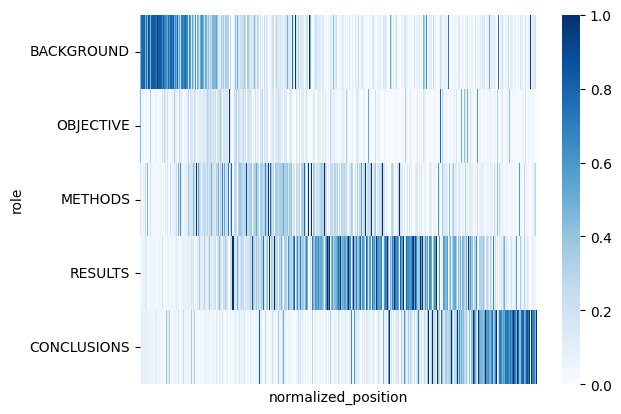

In [14]:
import seaborn as sns

sns.heatmap(abs_mean_plot_df.T.reindex(['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']),
            xticklabels=False, cmap='Blues',
            )

In [15]:
human_df_plot = pd.DataFrame(columns=['normalized_position', 'role', 'probability'])
df_list = []

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    if row['human_word_prob'] == []:
        continue
    df_melted = pd.DataFrame(row['human_word_prob']).melt(id_vars=['normalized_position'], var_name='role', value_name='probability')
    df_list.append(df_melted.dropna().reset_index(drop=True))

human_df_plot = pd.concat(df_list, ignore_index=True)
human_df_plot

100%|█████████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:32<00:00, 896.82it/s]


,normalized_position,role,probability
0,0.000000,BACKGROUND,0.000000
1,0.071429,BACKGROUND,0.000000
2,0.142857,BACKGROUND,0.000000
3,0.214286,BACKGROUND,0.000000
4,0.285714,BACKGROUND,0.558824
...,...,...,...
2352343,0.600000,NOVEL,1.000000
2352344,0.700000,NOVEL,0.000000
2352345,0.800000,NOVEL,0.000000
2352346,0.900000,NOVEL,0.000000


In [16]:
human_mean_plot_df = human_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)
# human_mean_plot_df = human_mean_plot_df.div(human_mean_plot_df.sum(axis=1), axis=0)
human_mean_plot_df

/tmp/ipykernel_1632624/3148390018.py:1: FutureWarning: The provided callable <function mean at 0x7f66105a6700> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  human_mean_plot_df = human_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)


role,BACKGROUND,CONCLUSIONS,METHODS,NOVEL,OBJECTIVE,RESULTS
normalized_position,,,,,,
0.000000,0.013245,0.01780,0.017921,0.917623,0.021253,0.012159
0.014925,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
0.015625,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000
0.016393,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000
0.016949,0.500000,0.00000,0.500000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
0.983051,0.000000,0.00000,0.000000,0.500000,0.000000,0.500000
0.983607,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000
0.984375,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000


<Axes: xlabel='normalized_position', ylabel='role'>

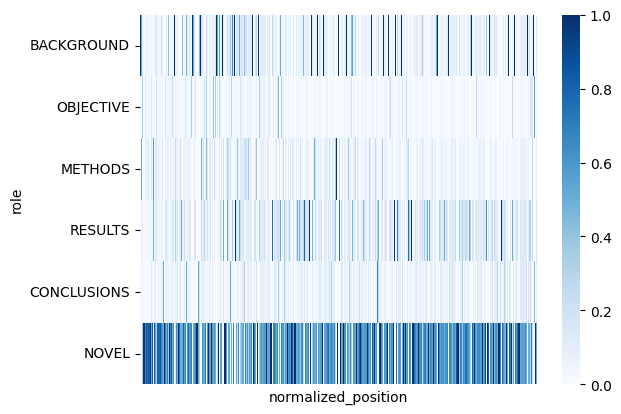

In [17]:
sns.heatmap(human_mean_plot_df.T.reindex(['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS', 'NOVEL']),
            xticklabels=False, cmap='Blues'
            )

# Prepare plot data

In [18]:
def concat_word_probs(df_filtered, model_name: str):
    """Step 1: 拼接所有文档的 word_prob（耗时）"""
    df_list = []
    
    for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
        if row[f'{model_name}_word_prob'] == []:
            continue
        df_melted = pd.DataFrame(row[f'{model_name}_word_prob']).melt(
            id_vars=['normalized_position'], var_name='role', value_name='probability')
        df_list.append(df_melted.dropna())
    
    return pd.concat(df_list, ignore_index=True)

# Step 1: 运行一次，缓存结果（耗时）
abs_concat = concat_word_probs(df_filtered, 'abs')
human_concat = concat_word_probs(df_filtered, 'human')
gemma4_concat = concat_word_probs(df_filtered, 'gemma4')
deepseek_r1_concat = concat_word_probs(df_filtered, 'deepseek_r1')
gpt_oss_concat = concat_word_probs(df_filtered, 'gpt_oss')
llama4_concat = concat_word_probs(df_filtered, 'llama4')
qwen3_6_concat = concat_word_probs(df_filtered, 'qwen3.6')

100%|█████████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:30<00:00, 943.93it/s]


In [19]:
def bin_and_aggregate(df_concat, n_bins=30):
    """Step 2: 分箱聚合（快速）"""
    bin_edges = np.linspace(0, 1, n_bins + 1).tolist()
    
    df_binned = df_concat.copy()
    df_binned['position_bin'] = pd.cut(
        df_binned['normalized_position'], 
        bins=bin_edges, 
        labels=range(n_bins),
        include_lowest=True
    )
    
    plot_df = df_binned.pivot_table(
        index='position_bin', 
        columns='role', 
        values='probability', 
        aggfunc='mean'
    ).fillna(0)
    
    return plot_df

# Step 2: 快速调整分箱参数
n_bins = 30
abs_plot_df = bin_and_aggregate(abs_concat, n_bins)
human_plot_df = bin_and_aggregate(human_concat, n_bins)
gemma4_plot_df = bin_and_aggregate(gemma4_concat, n_bins)
deepseek_r1_plot_df = bin_and_aggregate(deepseek_r1_concat, n_bins)
gpt_oss_plot_df = bin_and_aggregate(gpt_oss_concat, n_bins)
llama4_plot_df = bin_and_aggregate(llama4_concat, n_bins)
qwen3_6_plot_df = bin_and_aggregate(qwen3_6_concat, n_bins)

/tmp/ipykernel_1632624/2269064536.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = df_binned.pivot_table(
/tmp/ipykernel_1632624/2269064536.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = df_binned.pivot_table(
/tmp/ipykernel_1632624/2269064536.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = df_binned.pivot_table(
/tmp/ipykernel_1632624/2269064536.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a futu

In [20]:
for plot_df in [abs_plot_df, human_plot_df, gemma4_plot_df, deepseek_r1_plot_df, gpt_oss_plot_df, llama4_plot_df, qwen3_6_plot_df]:
    print(f"Mean NOVEL:")
    print(plot_df.NOVEL.mean())

Mean NOVEL:
0.0
Mean NOVEL:
0.62000235536513
Mean NOVEL:
0.32521934036908695
Mean NOVEL:
0.38634204087324014
Mean NOVEL:
0.48698027875205213
Mean NOVEL:
0.4073441621781589
Mean NOVEL:
0.3306686648621232


# Plot

/tmp/ipykernel_1632624/737243799.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Patch(facecolor=plt.cm.get_cmap(role_colors[role])(0.7), label=decapitalize_role[role])


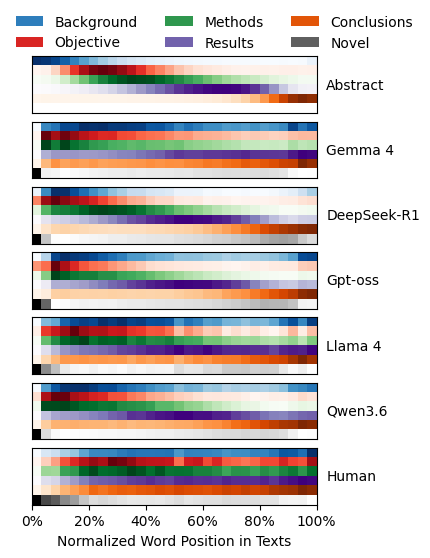

In [39]:
from matplotlib import pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import numpy as np

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

role_colors = {
    'BACKGROUND': 'Blues',
    'OBJECTIVE': 'Reds',
    'METHODS': 'Greens',
    'RESULTS': 'Purples',
    'CONCLUSIONS': 'Oranges',
    'NOVEL': 'Greys'
}

role_order = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS', 'NOVEL']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

def plot_multicolor_heatmap(df, ax):
    data = df.T.reindex(role_order)
    
    for i, role in enumerate(role_order):
        row_data = data.loc[role].values.reshape(1, -1)
        
        im = ax.imshow(row_data, aspect='equal', cmap=role_colors[role], interpolation='nearest', 
                       norm=colors.PowerNorm(gamma=1),
                       extent=[0, row_data.shape[1], i + 1, i])
    
    ax.set_ylim(len(role_order), 0)
    ax.set_xlim(0, data.shape[1])
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

gs_kw = dict(width_ratios=[25], height_ratios=[1, 1, 1, 1, 1, 1, 1])
fig, axes = plt.subplots(7, 1, gridspec_kw=gs_kw, figsize=(8, 5), layout="constrained")

dfs = [abs_plot_df, gemma4_plot_df, deepseek_r1_plot_df, 
       gpt_oss_plot_df, llama4_plot_df, qwen3_6_plot_df, human_plot_df]
titles = ['Abstract', 'Gemma 4', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3.6', 'Human']

for ax, df, title in zip(axes, dfs, titles):
    plot_multicolor_heatmap(df, ax)
    # 把 title 移到右侧，作为 ylabel
    ax.yaxis.set_label_position("right")
    ax.set_ylabel(title, rotation=0, ha='left', va='center', fontsize=10, labelpad=7)

axes[-1].set_xlabel('Normalized Word Position in Texts')
axes[-1].set_xticks(np.linspace(0, n_bins, 6))
axes[-1].set_xticklabels([f"{i*20}%" for i in range(6)])

legend_patches = [
    Patch(facecolor=plt.cm.get_cmap(role_colors[role])(0.7), label=decapitalize_role[role])
    for role in role_order
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.55, 1.10),
           ncol=len(role_order)/2, frameon=False, fontsize=10)

plt.show()

In [22]:
def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

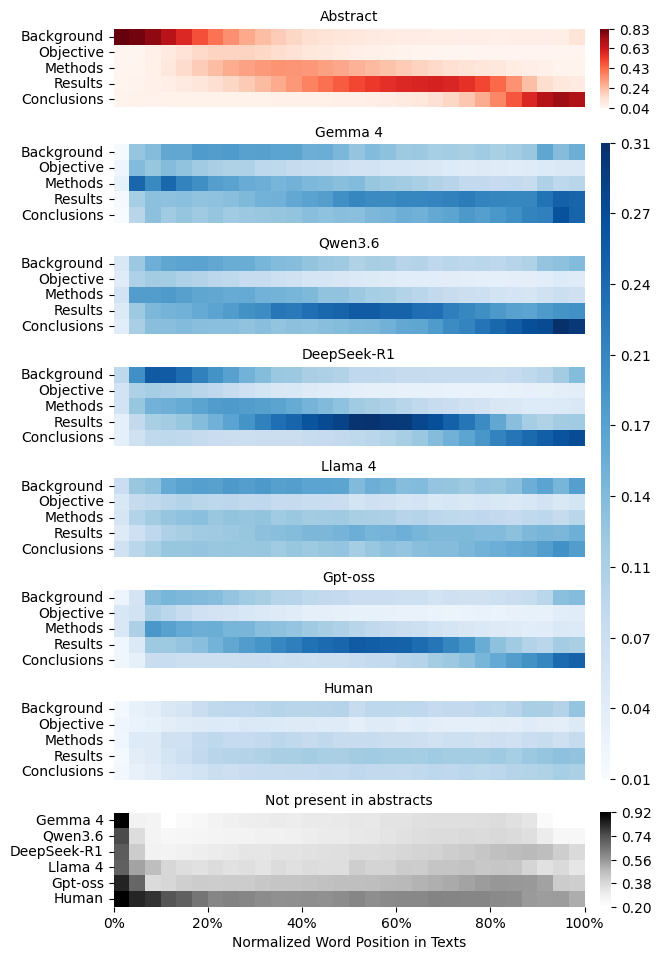

In [50]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

role_order_abs = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma4', 'qwen3_6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']
model_names = ['Gemma 4', 'Qwen3.6', 'DeepSeek-R1', 'Llama 4', 'Gpt-oss', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Not present in abstracts'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma4': gemma4_plot_df,
    'qwen3_6': qwen3_6_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'llama4': llama4_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_model_role_matrix(model, all_dfs, role_order):
    """构建某个 model 中所有 role 的数据矩阵（行是 role，列是 position）"""
    df = all_dfs[model]
    rows = []
    for role in role_order:
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(n_bins))
    return np.array(rows)

def get_novel_data_matrix(all_dfs, model_order):
    """构建所有 model 的 NOVEL 数据矩阵（行是 model，列是 position）"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if 'NOVEL' in df.columns:
            rows.append(df['NOVEL'].values)
        else:
            rows.append(np.zeros(n_bins))
    return np.array(rows)

# 创建图：
# 1. Abstract 子图 (5 行 role)
# 2. 6 个 model 子图 (每个 5 行 role)
# 3. NOVEL 子图 (6 行 model)
# 共 8 个子图
fig = plt.figure(figsize=(6.5, 9.5), layout="constrained")
height_ratios = [5] + [5] * 6 + [6]  # Abstract, 6 models, NOVEL
gs = gridspec.GridSpec(8, 1, figure=fig, height_ratios=height_ratios)

n_ticks = 5
gs_idx = 0

# 1. 绘制 Abstract 子图（红色）
ax_abs = fig.add_subplot(gs[gs_idx])
gs_idx += 1

abs_data_matrix = get_model_role_matrix('abs', all_plot_dfs, role_order_abs)
abs_vmin, abs_vmax = abs_data_matrix.min(), abs_data_matrix.max()

hm_abs = sns.heatmap(abs_data_matrix, ax=ax_abs, square=True, cmap='Reds',
                      cbar=True,
                      cbar_kws={'shrink': .9, 'aspect': 8, 'pad': -0.01},
                      vmin=abs_vmin, vmax=abs_vmax,
                      xticklabels=False,
                      yticklabels=[decapitalize_role[r] for r in role_order_abs],
                      rasterized=True)

cbar = hm_abs.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_abs.set_title('Abstract', fontsize=10, loc='center')
ax_abs.set_ylabel('')

# 2. 绘制 6 个 model 子图（蓝色，每个有自己的 colorbar）

# 计算所有非 NOVEL role 的 Summary 全局 vmin/vmax
non_novel_roles = [r for r in role_order if r != 'NOVEL']
global_sum_vmin = float('inf')
global_sum_vmax = float('-inf')

for role in non_novel_roles:
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    global_sum_vmin = min(global_sum_vmin, data_matrix.min())
    global_sum_vmax = max(global_sum_vmax, data_matrix.max())

for model, model_name in zip(model_order, model_names):
    ax = fig.add_subplot(gs[gs_idx])
    gs_idx += 1
    
    data_matrix = get_model_role_matrix(model, all_plot_dfs, role_order_abs)
    vmin, vmax = data_matrix.min(), data_matrix.max()
    
    hm = sns.heatmap(data_matrix, ax=ax, square=True, cmap='Blues',
                      cbar=False,
                      vmin=global_sum_vmin, vmax=global_sum_vmax,
                      xticklabels=False,
                      yticklabels=[decapitalize_role[r] for r in role_order_abs],
                      rasterized=True)
    
    ax.set_title(model_name, fontsize=10, loc='center')
    ax.set_ylabel('')

# 添加共享的 Summary colorbar（蓝色）
norm_sum = Normalize(vmin=global_sum_vmin, vmax=global_sum_vmax)
sm_sum = ScalarMappable(cmap='Blues', norm=norm_sum)
sm_sum.set_array([])
cbar_sum_ax = fig.add_axes([0.915, 0.185, 0.015, 0.67])
cbar_sum = fig.colorbar(sm_sum, cax=cbar_sum_ax)
cbar_sum.locator = ticker.LinearLocator(numticks=10)
cbar_sum.update_ticks()
cbar_sum.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 隐藏 Summary colorbar 的 spine
for spine in cbar_sum.ax.spines.values():
    spine.set_visible(False)

# 3. 绘制 NOVEL 子图（灰色）
ax_novel = fig.add_subplot(gs[gs_idx])

novel_data_matrix = get_novel_data_matrix(all_plot_dfs, model_order)
novel_vmin, novel_vmax = novel_data_matrix.min(), novel_data_matrix.max()

hm_novel = sns.heatmap(novel_data_matrix, ax=ax_novel, square=True, cmap='Greys',
                        cbar=True,
                        cbar_kws={'shrink': .9, 'aspect': 8, 'pad': -0.01},
                        vmin=novel_vmin, vmax=novel_vmax,
                        xticklabels=False,
                        yticklabels=model_names,
                        rasterized=True)

cbar = hm_novel.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_novel.set_title(decapitalize_role['NOVEL'], fontsize=10, loc='center')
ax_novel.set_ylabel('')

# 最后一个子图添加 x 轴标签
ax_novel.set_xticks(np.linspace(0, n_bins, 6))
ax_novel.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_novel.set_xlabel('Normalized Word Position in Texts')

plt.show()

In [41]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_1.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

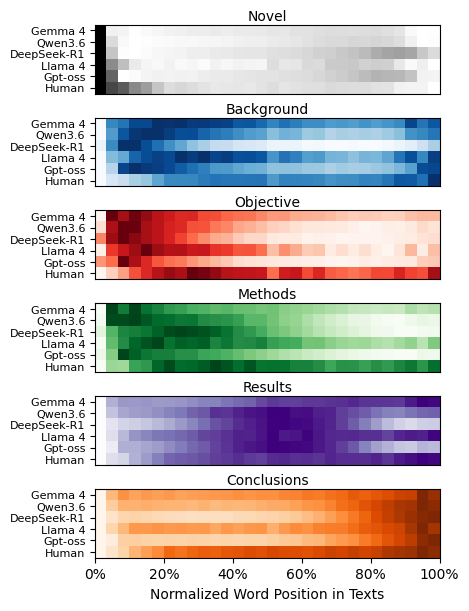

In [42]:
from matplotlib import pyplot as plt
import numpy as np

role_colors = {
    'BACKGROUND': 'Blues',
    'OBJECTIVE': 'Reds',
    'METHODS': 'Greens',
    'RESULTS': 'Purples',
    'CONCLUSIONS': 'Oranges',
    'NOVEL': 'Greys'
}

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma4', 'qwen3_6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']
model_names = ['Gemma 4', 'Qwen3.6', 'DeepSeek-R1', 'Llama 4', 'Gpt-oss', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma4': gemma4_plot_df,
    'qwen3_6': qwen3_6_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'llama4': llama4_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

global_vmax = max(
    df.values.max() for df in all_plot_dfs.values()
)
global_vmin = min(
    df.values.min() for df in all_plot_dfs.values()
)

def plot_role_across_models(role, ax, all_dfs, model_order):
    """绘制同一个 role 在不同 model 中的分布"""
    n_models = len(model_order)
    cmap = role_colors[role]
    
    for i, model in enumerate(model_order):
        df = all_dfs[model]
        if role in df.columns:
            row_data = df[role].values.reshape(1, -1)
        else:
            row_data = np.zeros((1, len(df)))
        
        im = ax.imshow(row_data, aspect='equal', cmap=cmap, 
                       interpolation='None',
                       # vmin=global_vmin, vmax=global_vmax,
                       extent=[0, row_data.shape[1], i + 1, i])
    
    ax.set_ylim(n_models, 0)
    ax.set_xlim(0, row_data.shape[1])
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# 创建图：5 行（5 个 role），每行 1 个子图
fig, axes = plt.subplots(6, 1, figsize=(10, 6), layout="constrained")

for ax, role in zip(axes, role_order):
    plot_role_across_models(role, ax, all_plot_dfs, model_order)
    
    # role 名称放在右侧
    ax.set_title(decapitalize_role[role], ha='center', va='center', fontsize=10, loc='center')
    
    # y 轴显示 model 名称
    ax.set_yticks(np.arange(0.5, len(model_order), 1))
    ax.set_yticklabels(model_names, fontsize=8)

# 最后一个子图添加 x 轴标签
axes[-1].set_xlabel('Normalized Word Position in Texts')
axes[-1].set_xticks(np.linspace(0, n_bins, 6))
axes[-1].set_xticklabels([f"{i*20}%" for i in range(6)])

plt.show()

In [43]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_4.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

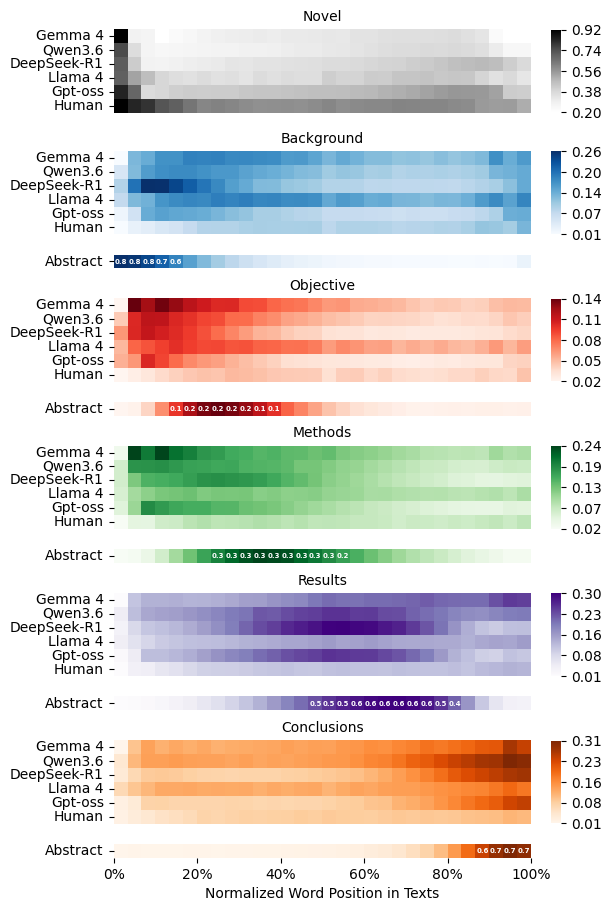

In [44]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_colors = {
    'BACKGROUND': 'Blues',
    'OBJECTIVE': 'Reds',
    'METHODS': 'Greens',
    'RESULTS': 'Purples',
    'CONCLUSIONS': 'Oranges',
    'NOVEL': 'Greys'
}

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma4', 'qwen3_6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']
model_names = ['Gemma 4', 'Qwen3.6', 'DeepSeek-R1', 'Llama 4', 'Gpt-oss', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma4': gemma4_plot_df,
    'qwen3_6': qwen3_6_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'llama4': llama4_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

# 创建图：NOVEL 只有 1 个子图，其他 role 有 2 个子图（Summary + abstract）
# 共 11 行：1 (NOVEL) + 2*5 (其他5个role)
fig = plt.figure(figsize=(6, 9), layout="constrained")
# height_ratios: NOVEL 6, 其他每个 role 是 [6, 1]
height_ratios = [6] + [6, 1] * 5
gs = gridspec.GridSpec(11, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0  # 当前 GridSpec 索引

for i, role in enumerate(role_order):
    if role == 'NOVEL':
        # NOVEL 只绘制模型子图，不绘制 abstract
        ax_sum = fig.add_subplot(gs[gs_idx])
        gs_idx += 1
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap=role_colors[role],
                          cbar=True,
                          cbar_kws={'shrink': 0.8, 'aspect': 8, 'pad': 0},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        n_ticks = 5
        cbar = hm1.collections[0].colorbar
        cbar.locator = ticker.LinearLocator(numticks=n_ticks)
        cbar.update_ticks()
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        
    else:
        # 其他 role 绘制模型子图 + abstract 子图
        ax_sum = fig.add_subplot(gs[gs_idx])
        ax_abs = fig.add_subplot(gs[gs_idx + 1])
        gs_idx += 2
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        abs_data = all_plot_dfs['abs'][role].values.reshape(1, -1) if role in all_plot_dfs['abs'].columns else np.zeros((1, n_bins))
        
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        abs_vmin, abs_vmax = abs_data.min(), abs_data.max()
        
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap=role_colors[role],
                          cbar=True,
                          cbar_kws={'shrink': 0.8, 'aspect': 8, 'pad': 0},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        hm2 = sns.heatmap(abs_data, ax=ax_abs, square=True, cmap=role_colors[role],
                          cbar=False,
                          vmin=abs_vmin, vmax=abs_vmax,
                          xticklabels=False,
                          yticklabels=['Abstract'])
        ax_abs.set_yticklabels(ax_abs.get_yticklabels(), rotation=0)
        
        # 在 abstract heatmap 单元格内标注较大的值
        threshold = abs_vmax * 0.7  # 只标注超过最大值 70% 的 cell
        for col_idx, val in enumerate(abs_data.flatten()):
            if val >= threshold:
                ax_abs.text(col_idx + 0.5, 0.5, f'{val:.1f}', 
                           ha='center', va='center',
                           fontsize=5, color='white', fontweight='bold')
        
        n_ticks = 5
        cbar = hm1.collections[0].colorbar
        
        cbar.locator = ticker.LinearLocator(numticks=n_ticks)
        cbar.update_ticks()
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        ax_abs.set_ylabel('')

# 最后一个 abstract 子图添加 x 轴标签
ax_abs.set_xticks(np.linspace(0, n_bins, 6))
ax_abs.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_abs.set_xlabel('Normalized Word Position in Texts')

plt.show()

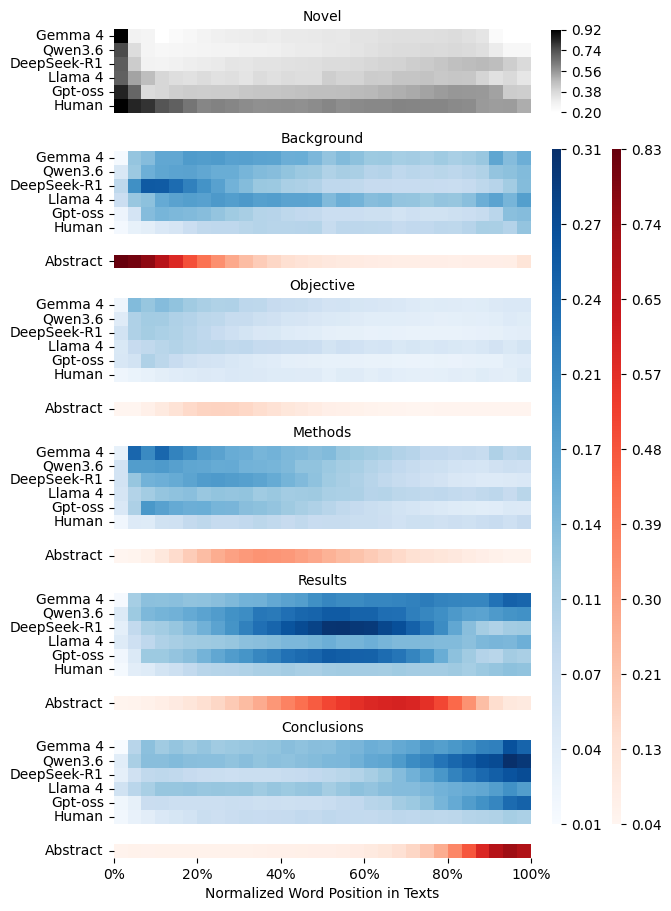

In [45]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma4', 'qwen3_6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']
model_names = ['Gemma 4', 'Qwen3.6', 'DeepSeek-R1', 'Llama 4', 'Gpt-oss', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma4': gemma4_plot_df,
    'qwen3_6': qwen3_6_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'llama4': llama4_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

# 计算所有非 NOVEL role 的 Summary 全局 vmin/vmax
non_novel_roles = [r for r in role_order if r != 'NOVEL']
global_sum_vmin = float('inf')
global_sum_vmax = float('-inf')
global_abs_vmin = float('inf')
global_abs_vmax = float('-inf')

for role in non_novel_roles:
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    global_sum_vmin = min(global_sum_vmin, data_matrix.min())
    global_sum_vmax = max(global_sum_vmax, data_matrix.max())
    
    # 计算 abstract 的全局 vmin/vmax
    if role in all_plot_dfs['abs'].columns:
        abs_data = all_plot_dfs['abs'][role].values
        global_abs_vmin = min(global_abs_vmin, abs_data.min())
        global_abs_vmax = max(global_abs_vmax, abs_data.max())

# 创建图：NOVEL 只有 1 个子图，其他 role 有 2 个子图（Summary + abstract）
fig = plt.figure(figsize=(6, 9), layout="constrained")
height_ratios = [6] + [6, 1] * 5
gs = gridspec.GridSpec(11, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0

for i, role in enumerate(role_order):
    if role == 'NOVEL':
        ax_sum = fig.add_subplot(gs[gs_idx])
        gs_idx += 1
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        
        # NOVEL 保持灰色，有自己的 colorbar
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Greys',
                          cbar=True,
                          cbar_kws={'shrink': 0.8, 'aspect': 8, 'pad': 0},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        n_ticks = 5
        cbar = hm1.collections[0].colorbar
        cbar.locator = ticker.LinearLocator(numticks=n_ticks)
        cbar.update_ticks()
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        
    else:
        ax_sum = fig.add_subplot(gs[gs_idx])
        ax_abs = fig.add_subplot(gs[gs_idx + 1])
        gs_idx += 2
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        abs_data = all_plot_dfs['abs'][role].values.reshape(1, -1) if role in all_plot_dfs['abs'].columns else np.zeros((1, n_bins))
        
        # Summary 使用蓝色，使用全局 vmin/vmax，不显示 colorbar
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                          cbar=False,
                          vmin=global_sum_vmin, vmax=global_sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        # Abstract 使用红色，使用全局 abstract vmin/vmax
        hm2 = sns.heatmap(abs_data, ax=ax_abs, square=True, cmap='Reds',
                          cbar=False,
                          vmin=global_abs_vmin, vmax=global_abs_vmax,
                          xticklabels=False,
                          yticklabels=['Abstract'])
        ax_abs.set_yticklabels(ax_abs.get_yticklabels(), rotation=0)
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        ax_abs.set_ylabel('')

ax_abs.set_xticks(np.linspace(0, n_bins, 6))
ax_abs.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_abs.set_xlabel('Normalized Word Position in Texts')

# 添加共享的 Summary colorbar（蓝色）
norm_sum = Normalize(vmin=global_sum_vmin, vmax=global_sum_vmax)
sm_sum = ScalarMappable(cmap='Blues', norm=norm_sum)
sm_sum.set_array([])
cbar_sum_ax = fig.add_axes([0.91, 0.09, 0.0155, 0.75])
cbar_sum = fig.colorbar(sm_sum, cax=cbar_sum_ax)
cbar_sum.locator = ticker.LinearLocator(numticks=10)
cbar_sum.update_ticks()
cbar_sum.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 添加共享的 Abstract colorbar（红色）
norm_abs = Normalize(vmin=global_abs_vmin, vmax=global_abs_vmax)
sm_abs = ScalarMappable(cmap='Reds', norm=norm_abs)
sm_abs.set_array([])
cbar_abs_ax = fig.add_axes([1.01, 0.09, 0.0155, 0.75])
cbar_abs = fig.colorbar(sm_abs, cax=cbar_abs_ax)
cbar_abs.locator = ticker.LinearLocator(numticks=10)
cbar_abs.update_ticks()
cbar_abs.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 隐藏 Summary colorbar 的 spine
for spine in cbar_sum.ax.spines.values():
    spine.set_visible(False)

# 隐藏 Abstract colorbar 的 spine
for spine in cbar_abs.ax.spines.values():
    spine.set_visible(False)

plt.show()

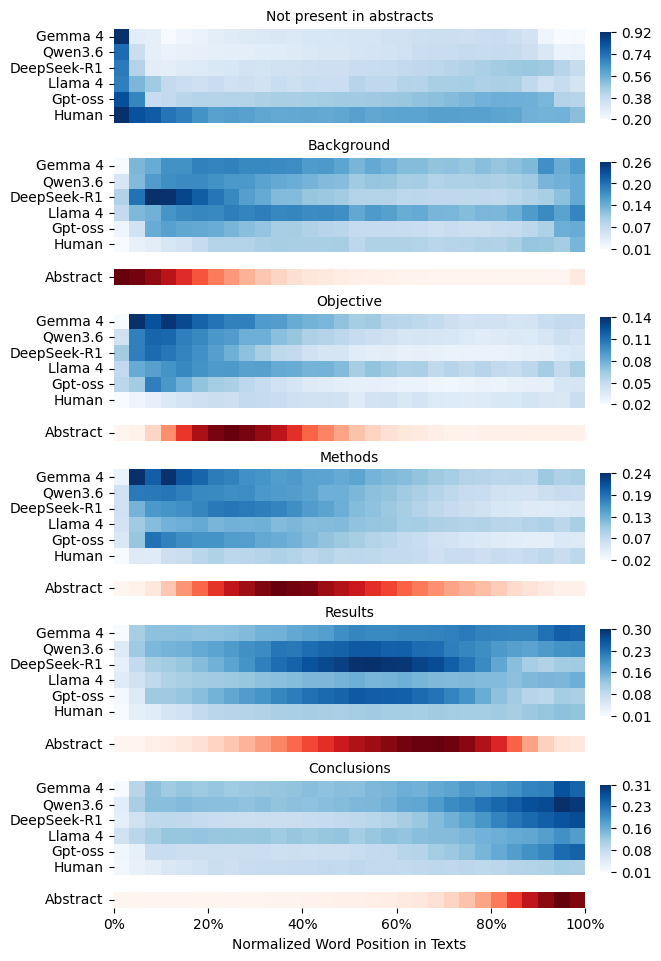

In [46]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma4', 'qwen3_6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']
model_names = ['Gemma 4', 'Qwen3.6', 'DeepSeek-R1', 'Llama 4', 'Gpt-oss', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Not present in abstracts'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma4': gemma4_plot_df,
    'qwen3_6': qwen3_6_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'llama4': llama4_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

# 创建图：NOVEL 只有 1 个子图，其他 role 有 2 个子图（Summary + abstract）
fig = plt.figure(figsize=(6.5, 9.5), 
                 layout="constrained"
                 )
height_ratios = [6] + [6, 1] * 5
gs = gridspec.GridSpec(11, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0

for i, role in enumerate(role_order):
    if role == 'NOVEL':
        ax_sum = fig.add_subplot(gs[gs_idx])
        gs_idx += 1
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        
        # NOVEL 保持灰色
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                          cbar=True,
                          cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names,
                          rasterized=True
                          )
        
    else:
        ax_sum = fig.add_subplot(gs[gs_idx])
        ax_abs = fig.add_subplot(gs[gs_idx + 1])
        gs_idx += 2
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        abs_data = all_plot_dfs['abs'][role].values.reshape(1, -1) if role in all_plot_dfs['abs'].columns else np.zeros((1, n_bins))
        
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        abs_vmin, abs_vmax = abs_data.min(), abs_data.max()
        
        # Summary 使用蓝色
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                          cbar=True,
                          cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names,
                          rasterized=True
                          )
        
        # Abstract 使用红色
        hm2 = sns.heatmap(abs_data, ax=ax_abs, square=True, cmap='Reds',
                          cbar=False,
                          vmin=abs_vmin, vmax=abs_vmax,
                          xticklabels=False,
                          yticklabels=['Abstract'],
                          rasterized=True
                          )

        ax_abs.set_yticklabels(ax_abs.get_yticklabels(), rotation=0)

    n_ticks = 5
    cbar = hm1.collections[0].colorbar
    
    cbar.locator = ticker.LinearLocator(numticks=n_ticks)
    cbar.update_ticks()
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    
    ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
    ax_sum.set_ylabel('')
    ax_abs.set_ylabel('')

ax_abs.set_xticks(np.linspace(0, n_bins, 6))
ax_abs.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_abs.set_xlabel('Normalized Word Position in Texts')

plt.show()

In [47]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_2.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

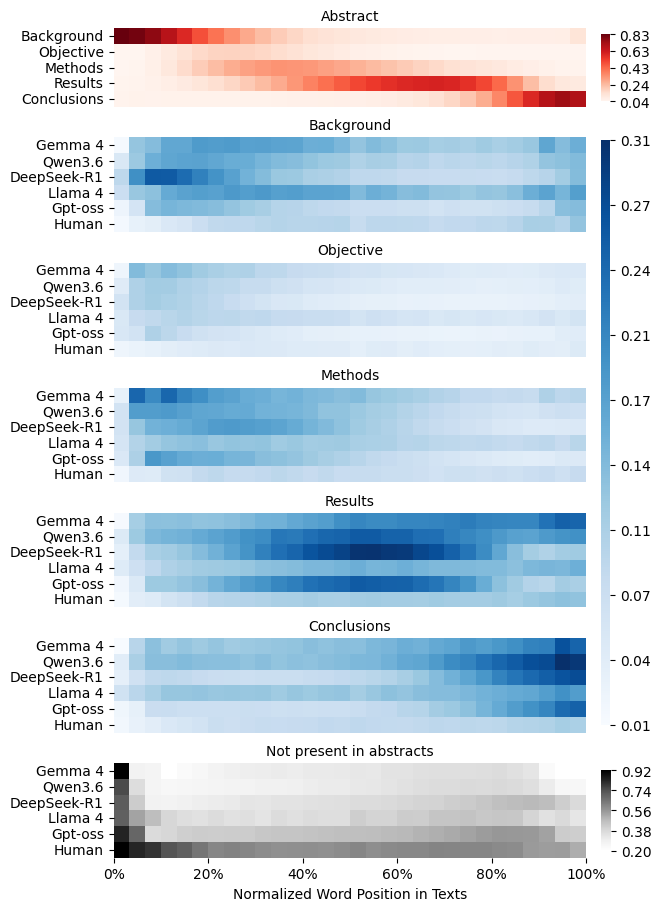

In [48]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_order_abs = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
role_order_novel = ['NOVEL']
model_order = ['gemma4', 'qwen3_6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']
model_names = ['Gemma 4', 'Qwen3.6', 'DeepSeek-R1', 'Llama 4', 'Gpt-oss', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Not present in abstracts'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma4': gemma4_plot_df,
    'qwen3_6': qwen3_6_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'llama4': llama4_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

def get_abs_data_matrix(all_dfs, role_order):
    """构建 abstract 中所有 role 的数据矩阵"""
    rows = []
    for role in role_order:
        if role in all_dfs['abs'].columns:
            rows.append(all_dfs['abs'][role].values)
        else:
            rows.append(np.zeros(n_bins))
    return np.array(rows)

# 创建图：
# 1. Abstract 子图 (5 行，每行一个 role)
# 2. NOVEL 子图 (6 行，每行一个 model)
# 3. 其他 5 个 role 的 Summary 子图 (每个 6 行)
# height_ratios: Abstract 5, NOVEL 6, 其他每个 role 6
fig = plt.figure(figsize=(6.5, 9), layout="constrained")
height_ratios = [5] + [6] + [6] * 5  # Abstract, NOVEL, 5 个其他 role
gs = gridspec.GridSpec(7, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0

# 1. 绘制 Abstract 子图（所有 role 在一起）
ax_abs = fig.add_subplot(gs[gs_idx])
gs_idx += 1

abs_data_matrix = get_abs_data_matrix(all_plot_dfs, role_order_abs)
abs_vmin, abs_vmax = abs_data_matrix.min(), abs_data_matrix.max()

hm_abs = sns.heatmap(abs_data_matrix, ax=ax_abs, square=True, cmap='Reds',
                      cbar=True,
                      cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                      vmin=abs_vmin, vmax=abs_vmax,
                      xticklabels=False,
                      yticklabels=[decapitalize_role[r] for r in role_order_abs],
                      rasterized=True)

n_ticks = 5
cbar = hm_abs.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_abs.set_title('Abstract', fontsize=10, loc='center')
ax_abs.set_ylabel('')

# 3. 绘制其他 5 个 role 的 Summary 子图
# 计算所有非 NOVEL role 的 Summary 全局 vmin/vmax
non_novel_roles = [r for r in role_order if r != 'NOVEL']
global_sum_vmin = float('inf')
global_sum_vmax = float('-inf')

for role in non_novel_roles:
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    global_sum_vmin = min(global_sum_vmin, data_matrix.min())
    global_sum_vmax = max(global_sum_vmax, data_matrix.max())

for role in role_order_abs:
    ax_sum = fig.add_subplot(gs[gs_idx])
    gs_idx += 1
    
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
    
    hm = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                      cbar=False,
                      cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                      vmin=global_sum_vmin, vmax=global_sum_vmax,
                      xticklabels=False,
                      yticklabels=model_names,
                      rasterized=True)
    
    # cbar = hm.collections[0].colorbar
    # cbar.locator = ticker.LinearLocator(numticks=n_ticks)
    # cbar.update_ticks()
    # cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    
    ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
    ax_sum.set_ylabel('')

# 添加共享的 Summary colorbar（蓝色）
norm_sum = Normalize(vmin=global_sum_vmin, vmax=global_sum_vmax)
sm_sum = ScalarMappable(cmap='Blues', norm=norm_sum)
sm_sum.set_array([])
cbar_sum_ax = fig.add_axes([0.915, 0.2, 0.015, 0.65])
cbar_sum = fig.colorbar(sm_sum, cax=cbar_sum_ax)
cbar_sum.locator = ticker.LinearLocator(numticks=10)
cbar_sum.update_ticks()
cbar_sum.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 隐藏 Summary colorbar 的 spine
for spine in cbar_sum.ax.spines.values():
    spine.set_visible(False)

# 2. 绘制 NOVEL 子图
ax_novel = fig.add_subplot(gs[gs_idx])
gs_idx += 1

data_matrix = get_role_data_matrix('NOVEL', all_plot_dfs, model_order)
sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()

hm_novel = sns.heatmap(data_matrix, ax=ax_novel, square=True, cmap='Greys',
                        cbar=True,
                        cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                        vmin=sum_vmin, vmax=sum_vmax,
                        xticklabels=False,
                        yticklabels=model_names,
                        rasterized=True)

cbar = hm_novel.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_novel.set_title(decapitalize_role['NOVEL'], fontsize=10, loc='center')
ax_novel.set_ylabel('')


# 最后一个子图添加 x 轴标签
ax_novel.set_xticks(np.linspace(0, n_bins, 6))
ax_novel.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_novel.set_xlabel('Normalized Word Position in Texts')

plt.show()

In [49]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_3.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

# Save fig

In [51]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

# Top-10 novel words

In [33]:
from tqdm import tqdm

results = {'gemma4': {}, 'qwen3.6': {}, 'deepseek_r1': {}, 'llama4': {}, 'gpt_oss': {}, 'human': {}}
for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    for model in ['gemma4', 'qwen3.6', 'deepseek_r1', 'llama4', 'gpt_oss', 'human']:
        for word, role_prob_dict in zip(row[f'{model}_words'], row[f'{model}_word_prob']):
            if role_prob_dict['NOVEL'] == 1.0 and role_prob_dict['normalized_position'] < 0.2:
                results[model][word] = results[model].get(word, 0) + 1

  0%|                                                                                                  | 0/29110 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 29110/29110 [00:01<00:00, 14873.95it/s]


,gemma4,qwen3.6,deepseek_r1,llama4,gpt_oss,human
study,1573.0,3415.0,15735.0,4723.0,13361.0,5936.0
authors,302.0,184.0,284.0,3131.0,6529.0,637.0
Identifies,7096.0,1586.0,255.0,1062.0,352.0,82.0
shows,13.0,134.0,82.0,162.0,6264.0,1893.0
identifies,431.0,933.0,4328.0,450.0,1928.0,362.0
reveals,853.0,1613.0,2635.0,404.0,2065.0,193.0
demonstrates,637.0,991.0,2252.0,753.0,1445.0,1046.0
investigates,2.0,114.0,5612.0,500.0,3.0,40.0
paper,1.0,212.0,23.0,9.0,117.0,5233.0
Demonstrates,811.0,2904.0,142.0,482.0,123.0,185.0


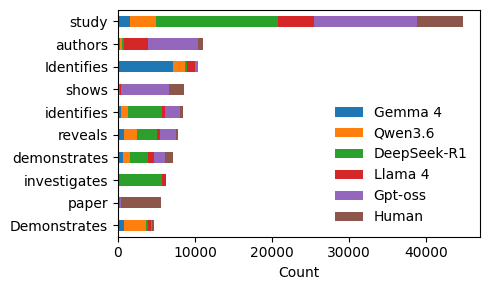

In [52]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

model_name_dict = {
    'gemma4': 'Gemma 4',
    'qwen3.6': 'Qwen3.6',
    'deepseek_r1': 'DeepSeek-R1',
    'llama4': 'Llama 4',
    'gpt_oss': 'Gpt-oss',
    'human': 'Human'
}

top_10_novel_words_df = pd.DataFrame.from_dict(results, orient='columns').loc[pd.DataFrame.from_dict(results, orient='columns').sum(axis=1).sort_values(ascending=False)[0:10].index]

display(top_10_novel_words_df)

# 重命名列
top_10_novel_words_df = top_10_novel_words_df.rename(columns=model_name_dict)

fig, ax = plt.subplots(figsize=(5, 3))

# 使用 pandas 的 barh 绘制堆叠条形图
top_10_novel_words_df.plot.barh(stacked=True, ax=ax)

ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(frameon=False, title='', loc='lower right')
ax.invert_yaxis()  # 让最多的在上面

plt.tight_layout()
plt.show()

In [53]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/novel_top10_words.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )